<a href="https://colab.research.google.com/github/SManojna/ai-engineering/blob/main/reviews%20/01-gpt-from-scratch/gpt-code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import urllib.request

# 1. Download the actual raw text
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
with urllib.request.urlopen(url) as response:
    text = response.read().decode('utf-8')

# 2. Save it correctly to your local input.txt file
with open('input.txt', 'w', encoding='utf-8') as f:
    f.write(text)

In [2]:
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [3]:
len(text)

1115394

In [4]:
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



# Vocab -> all the characters in the data

In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


# ENCODING - DECODING

In [6]:
#tokenizing  and detokenizing the text
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s] #encoding each character
decode = lambda l: ''.join([itos[i] for i in l]) # decoding and joining them back to string

print(encode("Hello, How are you?"))
print(decode(encode("Hello, How are you?")))


[20, 43, 50, 50, 53, 6, 1, 20, 53, 61, 1, 39, 56, 43, 1, 63, 53, 59, 12]
Hello, How are you?


In [7]:
# as the vocab list is small, we get a long seq of integers for encoding

In [8]:
import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
# data.shape is the len(text)
print(data[:1000])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [9]:
n=int(0.9*len(data))
train_data=data[:n]
val_data = data[n:]

In [10]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

# CONTEXT AND TARGET

In [11]:
# context and target
x = train_data[:block_size]
print(x)
y = train_data[1:block_size+1]
print(y)

for t in range(block_size):
  context = x[:t+1]
  target = y[t]
  print(f"when context is {context} target is -> {target}")

tensor([18, 47, 56, 57, 58,  1, 15, 47])
tensor([47, 56, 57, 58,  1, 15, 47, 58])
when context is tensor([18]) target is -> 47
when context is tensor([18, 47]) target is -> 56
when context is tensor([18, 47, 56]) target is -> 57
when context is tensor([18, 47, 56, 57]) target is -> 58
when context is tensor([18, 47, 56, 57, 58]) target is -> 1
when context is tensor([18, 47, 56, 57, 58,  1]) target is -> 15
when context is tensor([18, 47, 56, 57, 58,  1, 15]) target is -> 47
when context is tensor([18, 47, 56, 57, 58,  1, 15, 47]) target is -> 58


In [12]:
torch.manual_seed(1337)
batch_size = 4 #no of parallel executions
block_size = 8 # max context length

def get_batch(split):
  data = train_data if split=='train' else val_data
  ix = torch.randint((len(data)-block_size), (batch_size,))
  # len(data)-block_size -> upper bound for selecting the number
  # (batch_size,) -> creates 1D tensor of size as batch_size
  # print(ix)
  x = torch.stack([data[i:block_size+i] for i in ix])
  y = torch.stack([data[i+1:block_size+i+1] for i in ix]) # y is x with offset of 1
  # x and y are stacked up
  return x,y

xb, yb = get_batch('train')
print('inputs')
print(xb.shape)
print(xb)
print('targets')
print(yb.shape)
print(yb)


print('--------------------------')
for b in range(batch_size):
  for t in range(block_size):
    context = xb[b,:t+1]
    target = yb[b,t]
    print(f"when context is {context.tolist()} target is -> {target}")



inputs
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
--------------------------
when context is [24] target is -> 43
when context is [24, 43] target is -> 58
when context is [24, 43, 58] target is -> 5
when context is [24, 43, 58, 5] target is -> 57
when context is [24, 43, 58, 5, 57] target is -> 1
when context is [24, 43, 58, 5, 57, 1] target is -> 46
when context is [24, 43, 58, 5, 57, 1, 46] target is -> 43
when context is [24, 43, 58, 5, 57, 1, 46, 43] target is -> 39
when context is [44] target is -> 53
when context is [44, 53] target is -> 56
when context is [44, 53, 56] target is -> 1
when context is [44, 53, 56, 1] target is -> 58
when context i

In [13]:
xb

tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])

# BIGram Implementation

In [14]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)


class BigramLanguageModel(nn.Module):

  def __init__(self, vocab_size):
    # constructor of parent class nn.Module
    super().__init__()
    #each char from vocab_size directly reads off the logits
    # for next token from a lookup table
    self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
    # creating a token embedding with input dim as vocal_size and output dim as vocab_size
    # output vectors are logits
    #When you give this embedding table a character's integer ID (e.g., `5` for `'`), it returns a row of `vocab_size` numbers.
    # Each number in that row is the *score* for what character is likely to come *after* the character represented by `5`.



  def forward(self, idx, targets=None):
    # idx, targets -> shape is (Batch_size,block_size) i.e, (B,T) tensors
    logits = self.token_embedding_table(idx) # (B,T,C)
    # For each character ID in idx, the nn.Embedding layer looks up its corresponding row of logits.

    if targets is None:
        loss = None
    else:
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        # making logits, 2D as cross_entropy expects perdiction to be 2D
        targets = targets.view(B*T)
        # making it 1D
        loss = F.cross_entropy(logits, targets)

    return logits, loss


  def generate(self, idx, max_new_tokens):
    """ considers seq idx and tries to predict max_new_tokens following"""
    # idx is (B, T) array of indices -> current context
    # max_new_tokens -> number of new characters model should generate
    for _ in range(max_new_tokens):
      # get the predictions -> calls the forward method
      logits, loss = self(idx) # equivalent to calling self.forward(idx,targets=None)
      # considering only the last step
      logits = logits[:,-1,:] # becomes (B,C)
      #applying softmax -> converting logits to probabilities, dim = -1 -> ensures softmax is applied across C
      probs = F.softmax(logits, dim=-1) # (B,C)
      # sample from distribution
        # It takes the probs (which is (B, C)) and, for each batch element, randomly picks one character index from the C possible characters, weighted by their probabilities.
        # num_samples = 1 means we want to sample only one next character for each sequence in the batch.
      idx_next = torch.multinomial(probs,num_samples = 1) # (B,1)
      # append sampled index to running sequence
      idx = torch.cat((idx, idx_next), dim=1) # (B,T+1)
    return idx



m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

print(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100))
print(decode(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)
tensor([[ 0, 31, 23, 21, 41, 24, 32, 11, 13, 41, 17, 24, 25, 53, 32, 40, 60, 38,
         60,  1, 15, 12, 52, 55,  7, 29, 17,  9,  9, 10, 15, 22, 55, 49, 27, 23,
         20,  7, 55, 11, 10, 50, 39,  2, 53, 47, 63, 61, 49, 20, 48, 45, 15, 46,
         64, 40, 29, 12, 59,  2,  9, 40, 24, 21, 45, 61, 43, 60, 51, 63, 18, 22,
         19, 33, 19, 54,  0, 61, 52, 37, 35, 51, 52, 62, 23, 35, 35, 43, 60,  7,
         58, 16, 55, 36, 17, 56, 34, 23, 24, 45, 22]])

pJ:Bpm&yiltNCjeO3:Cx&vvMYW-txjuAd IRFbTpJ$zkZelxZtTlHNzdXXUiQQY:qFINTOBNLI,&oTigq z.c:Cq,SDXzetn3XVj


Optimizer

In [15]:
#training the model
lr = learning_rate = 1e-3
optimizer = torch.optim.AdamW(m.parameters(), lr=learning_rate)

In [16]:
batch_size = 32
for s in range(100):
  # sample a batch of data
  xb, yb = get_batch('train')

  #evaluate the loss -> calls forward function
  logits, loss = m(xb, yb)
  # zero_grad -> clears prev grad, set_to_none =True -> memory efficient way of clearing grad
  optimizer.zero_grad(set_to_none=True)
  # loss.backward -> does backward pass
  loss.backward()
  # hyper parameter tuning to minimize loss
  optimizer.step()


print(loss.item())

4.554598808288574


In [17]:
print(decode(m.generate(idx=torch.zeros((1,1),dtype=torch.long), max_new_tokens=400)[0].tolist()))


wBM;o-opr$mOiPJEYD-CfigkzD3p3?zvS;ADz;.y?o,ivCuC'zqHxcVT cHA
rT'Fd,SBMZyOslg!NXeF$sBe,juUzLq?w-wzP-h
ERjjxlgJzPbHxf$ q,q,KCDCU fqBOQT
SV&CW:xSVwZv'DG'NSPypDhKStKzC -$hslxIVzoivnp ,ethA:NCCGoi
tN!ljjP3fwJMwNelgUzzPGJlgihJ!d?q.d
pSPYgCuCJrIFtb
jQXg
pA.P LP,SPJi
DBcuBM:CixjJ$Jzkq,OLI3KLQLMGph$O 3DfiPHnXKuHMlyjxEiyZib3FsCV-oJa!zoc'XSP :CKGUhd?lgCOF$;;DTHZMlvvcmZAm;:iv'MMgO&Ywbc;BLCUd&vZINLIzkuTGZa
D.?


In [18]:
eval_iters = 200

# Calculating Loss

In [19]:
# estimate loss
# no_grad -> as we dont want to do back prop
# so no need to store values
@torch.no_grad()
def estimate_loss():
  out = {}
  # setting model to eval phase
  m.eval()
  for split in ['train', 'val']:
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
      X,Y = get_batch(split)
      logits, loss = m(X,Y)
      losses[k] = loss.item()
    out[split]= losses.mean()
  # setting model to training phase
  m.train()
  return out

In [20]:
max_iters = 3000
eval_interval = 300

# Training and Evaluation

In [21]:
for iter in range(max_iters):
  # evaluating loss on train and eval sets
  if iter % eval_interval == 0:
    losses = estimate_loss()
    print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

  xb, yb = get_batch('train')

  logits, loss = m(xb, yb)
  optimizer.zero_grad(set_to_none=True)
  loss.backward()
  optimizer.step()

step 0: train loss 4.6075, val loss 4.6058
step 300: train loss 4.2792, val loss 4.2796
step 600: train loss 3.9857, val loss 3.9960
step 900: train loss 3.7328, val loss 3.7363
step 1200: train loss 3.5069, val loss 3.5119
step 1500: train loss 3.3168, val loss 3.3311
step 1800: train loss 3.1641, val loss 3.1738
step 2100: train loss 3.0395, val loss 3.0463
step 2400: train loss 2.9361, val loss 2.9402
step 2700: train loss 2.8456, val loss 2.8603


In [22]:
print(decode(m.generate(idx=torch.zeros((1,1),dtype=torch.long), max_new_tokens=500)[0].tolist()))


SGr qbr wr. YO,istKIFDusoisbrIRSlangK:wast sQXkis irSAyzPm;Kuene.
AWhz'TER:vvXxf. by co tches ber ba;ERJUCWeselithBRtSt
BUAhu gFVOKQ?pely Xere ERAwonn
JG&vit my i?d:


WI& d.p whe thi,S::
.juy,
'jnoickejRj3QEr?O.
Wbine tRLIulatrs 
WgVThWIKInor, a
IIUGlkUEhTV?:; palasto.

A nQkigngOLTodgonumbet fBGs sArv&CUR:k.imptSimy,lSAKRjbXat I BYomyy,e bLIomonergls! gno?ni.f filiulDUEMyea!
OwF. E; ia!UCjon -p ad bjofN&ystlveve Im,
pe,. 
Wat, y p aket3CRCJUVXFostoisuUSthateefapsshiad.
o dedishem'd.
SPm tSBDWh


Self -Attention (Mathematical trick)

In [23]:
torch.manual_seed(1337)
B, T, C = 4,8,2
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

**Version 1 **

In [24]:
# xbow -> x bag of words -> context of previous words till current
# xbow[b,t] = mean(x[b,i]) where i <=t
# b -> batch, t -> time , C -> Channel
xbow = torch.zeros((B,T,C))
for b in range(B):
  for t in range(T):
    # current batch and everything until t th token
    xprev = x[b,:t+1] # (t, C)
    # averaging out on the 0th dim
    xbow[b,t] = torch.mean(xprev, 0 )

In [25]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [26]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

in the above, the first arrays are the same, the some on on xbow is the avg of first 2, 3rd one is avg of first 3  of x and this is very in-efficient

So a matrix mul is required

In [27]:
torch.manual_seed(42)
a = torch.ones(3,3)
b = torch.randint(0,10,(3,2)).float()
c = a@b # matrix multiplication
print('a - ')
print(a)
print('b -')
print(b)
print('c - ')
print(c)

a - 
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
b -
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
c - 
tensor([[14., 16.],
        [14., 16.],
        [14., 16.]])


In [28]:
torch.tril(torch.ones(3,3)) # torch.tril -> gives lower tirangurlar matrix

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

doing avgs in incremental fashion

In [29]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3,3))
# normalization of a
# along dim 1 -> columns -> so rows are normalised
''' becomes tensor([[1.0000, 0.0000, 0.0000],  # 1/1, 0/1, 0/1
        [0.5000, 0.5000, 0.0000],  # 1/2, 1/2, 0/2
        [0.3333, 0.3333, 0.3333]]) # 1/3, 1/3, 1/3 '''
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a@b # matrix multiplication
print('a - ')
print(a)
print('b -')
print(b)
print('c - ')
print(c)

a - 
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
b -
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
c - 
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


**Version 2 - Weighted sum **

In [30]:
wei = torch.tril(torch.ones(T,T))
wei = wei/ wei.sum(1, keepdim=True)
xbow2 = wei @ x # actual shape (T,T) @ (B,T,C) -> creates (B, T, T) @ (B, T,C)-> (B, T, C)
xbow2

tensor([[[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]],

        [[ 1.3488, -0.1396],
         [ 0.8173,  0.4127],
         [-0.1342,  0.4395],
         [ 0.2711,  0.4774],
         [ 0.2421,  0.0694],
         [ 0.0084,  0.0020],
         [ 0.0712, -0.1128],
         [ 0.2527,  0.2149]],

        [[-0.6631, -0.2513],
         [ 0.1735, -0.0649],
         [ 0.1685,  0.3348],
         [-0.1621,  0.1765],
         [-0.2312, -0.0436],
         [-0.1015, -0.2855],
         [-0.2593, -0.1630],
         [-0.3015, -0.2293]],

        [[ 1.6455, -0.8030],
         [ 1.4985, -0.5395],
         [ 0.4954,  0.3420],
         [ 1.0623, -0.1802],
         [ 1.1401, -0.4462],
         [ 1.0870, -0.4071],
         [ 1.0430, -0.1299],
         [ 1.1138, -0.1641]]])

In [31]:
# checking if xbow and xbow2 are the same
torch.allclose(xbow, xbow2)

False

In [32]:
xbow[0], xbow2[0] # almost identical

(tensor([[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]]),
 tensor([[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]]))

**Version 3 -> using softmax**

In [33]:
tril = torch.tril(torch.ones(T,T))
tril


tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])

In [34]:
wei = torch.zeros((T,T))
wei

tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [35]:
# masking the zeros of tril with -inf
wei = wei.masked_fill(tril==0, float('-inf'))
wei

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [36]:
# normalization using softmax -> exponentialing and then diving by the exponentiated sum
wei = F.softmax(wei, dim=-1)
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [37]:
x

tensor([[[ 0.1808, -0.0700],
         [-0.3596, -0.9152],
         [ 0.6258,  0.0255],
         [ 0.9545,  0.0643],
         [ 0.3612,  1.1679],
         [-1.3499, -0.5102],
         [ 0.2360, -0.2398],
         [-0.9211,  1.5433]],

        [[ 1.3488, -0.1396],
         [ 0.2858,  0.9651],
         [-2.0371,  0.4931],
         [ 1.4870,  0.5910],
         [ 0.1260, -1.5627],
         [-1.1601, -0.3348],
         [ 0.4478, -0.8016],
         [ 1.5236,  2.5086]],

        [[-0.6631, -0.2513],
         [ 1.0101,  0.1215],
         [ 0.1584,  1.1340],
         [-1.1539, -0.2984],
         [-0.5075, -0.9239],
         [ 0.5467, -1.4948],
         [-1.2057,  0.5718],
         [-0.5974, -0.6937]],

        [[ 1.6455, -0.8030],
         [ 1.3514, -0.2759],
         [-1.5108,  2.1048],
         [ 2.7630, -1.7465],
         [ 1.4516, -1.5103],
         [ 0.8212, -0.2115],
         [ 0.7789,  1.5333],
         [ 1.6097, -0.4032]]])

In [38]:
xbow3 = wei@x
xbow3

tensor([[[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]],

        [[ 1.3488, -0.1396],
         [ 0.8173,  0.4127],
         [-0.1342,  0.4395],
         [ 0.2711,  0.4774],
         [ 0.2421,  0.0694],
         [ 0.0084,  0.0020],
         [ 0.0712, -0.1128],
         [ 0.2527,  0.2149]],

        [[-0.6631, -0.2513],
         [ 0.1735, -0.0649],
         [ 0.1685,  0.3348],
         [-0.1621,  0.1765],
         [-0.2312, -0.0436],
         [-0.1015, -0.2855],
         [-0.2593, -0.1630],
         [-0.3015, -0.2293]],

        [[ 1.6455, -0.8030],
         [ 1.4985, -0.5395],
         [ 0.4954,  0.3420],
         [ 1.0623, -0.1802],
         [ 1.1401, -0.4462],
         [ 1.0870, -0.4071],
         [ 1.0430, -0.1299],
         [ 1.1138, -0.1641]]])

# Self Attention in BiGram
Learning Richer Token Meanings: The primary goal is to allow the model to learn dense, continuous vector representations (embeddings) for each character. Instead of just directly predicting the next character based on the current one's ID, these embeddings capture semantic and contextual information. This is essential for understanding relationships between characters and words that go beyond simple direct transitions.

Increased Model Capacity and Expressiveness: By introducing an embedding dimension (n_embd), the model gains more parameters and a more flexible architecture. This allows it to learn more complex patterns in the data, leading to better predictions and more coherent text generation.

Modularity and Scalability: Separating the embedding lookup from the final prediction head makes the model more modular. The embedding layer focuses on representing tokens, while a separate linear layer (lm_head) translates these representations into prediction scores. This design is highly scalable and forms the basis for modern deep learning architectures where embeddings are processed through multiple layers before final predictions.


Enriching Contextual Information: By adding positional embeddings, the model can now combine information about what a token is with where it is. This richer representation helps the model understand the grammatical structure, dependencies, and overall meaning of a sequence much better, leading to more accurate predictions.

---



In [46]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

n_embd = 32

class BigramLanguageModel(nn.Module):

  def __init__(self, vocab_size):
    # constructor of parent class nn.Module
    super().__init__()
    #each char from vocab_size directly reads off the logits
    # for next token from a lookup table
    self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
    # returns n_embd -> dimensional vector for each token
    # n_embd -> token embedding
    self.position_embedding_table = nn.Embedding(block_size, n_embd)
    # it will learn a unique n_embd-dimensional embedding for each possible position
    # within the maximum sequence length (block_size).
    self.lm_head = nn.Linear(n_embd, vocab_size)
    # take n_embd token embedding and project up to  vocab_size dim
    # vocab_size logits are predicting next character


  def forward(self, idx, targets=None):
    B, T  = idx.shape


    # idx, targets -> shape is (Batch_size,block_size) i.e, (B,T) tensors
    tok_emb = self.token_embedding_table(idx) # (B,T,C)
    # gets token embeddings
    # passes the embedding through lm_head to get final logits
    pos_emb = self.position_embedding_table(torch.arange(T)) # (T,C)
    # torch.arange(T) creates a tensor like [0, 1, 2, ..., T-1], representing
    # the positions of tokens in the current sequence.
    x = tok_emb + pos_emb # (B,T,C)
    logits = self.lm_head(x) # (B,T,vocab_size)

    if targets is None:
        loss = None
    else:
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        # making logits, 2D as cross_entropy expects perdiction to be 2D
        targets = targets.view(B*T)
        # making it 1D
        loss = F.cross_entropy(logits, targets)

    return logits, loss


  def generate(self, idx, max_new_tokens):
    """ considers seq idx and tries to predict max_new_tokens following"""
    # idx is (B, T) array of indices -> current context
    # max_new_tokens -> number of new characters model should generate
    for _ in range(max_new_tokens):
      # get the predictions -> calls the forward method
      idx_cond = idx[:, -block_size:]
      logits, loss = self(idx_cond) # equivalent to calling self.forward(idx,targets=None)
      # considering only the last step
      logits = logits[:,-1,:] # becomes (B,C)
      #applying softmax -> converting logits to probabilities, dim = -1 -> ensures softmax is applied across C
      probs = F.softmax(logits, dim=-1) # (B,C)
      # sample from distribution
        # It takes the probs (which is (B, C)) and, for each batch element, randomly picks one character index from the C possible characters, weighted by their probabilities.
        # num_samples = 1 means we want to sample only one next character for each sequence in the batch.
      idx_next = torch.multinomial(probs,num_samples = 1) # (B,1)
      # append sampled index to running sequence
      idx = torch.cat((idx, idx_next), dim=1) # (B,T+1)
    return idx



m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

print(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100))
print(decode(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

torch.Size([256, 65])
tensor(4.4680, grad_fn=<NllLossBackward0>)
tensor([[ 0, 31, 51, 34, 42, 42, 53, 51, 27, 34, 35, 63, 42, 49,  9,  5, 14, 56,
         50, 23,  0, 29, 42, 59, 35, 19, 19, 20, 28, 51, 47, 59,  4, 33, 36, 14,
         50, 21, 20, 32, 38,  5, 63, 44, 57, 16, 59, 17, 58, 55, 35, 28, 33, 50,
         27, 38, 58,  4,  7, 50, 34,  4, 55, 14, 53, 46, 61, 26,  8, 50, 11, 26,
          9, 64, 10, 51, 47, 47, 51, 61, 60, 45,  6, 45, 13, 53,  9, 17, 28, 26,
          9, 46, 27, 61,  3,  2, 34, 63, 32, 59, 17]])

HLzwBuivzXDvzYGHliBmy,iVEDl-xKn;tbUldzTmrljov&qy$vCXc3hResa!iHmPs!d-LCT:!ByqsqEHdFmmlH;uNhVosxGhfHhE


In summary, the new implementation introduces the concept of rich token embeddings and position embeddings (n_embd) and separates the embedding process from the final prediction step using a dedicated linear layer (lm_head).enhances the model's ability to process and understand sequential data, moving it closer to the capabilities of modern Transformer models.

# Version 4 -> Self - attention !

In [40]:
torch.manual_seed(1337)

B, T,C = 4,8, 32
x = torch.randn(B,T,C)

# single head performing self attention
head_size = 16
key = nn.Linear(C, head_size, bias = False)
query = nn.Linear(C, head_size, bias = False)
value = nn.Linear(C, head_size, bias = False)
k = key(x)
q = query(x)

# Formula for wei (attention weights) from 'Attention Is All You Need':
# wei = softmax(QK^T / sqrt(head_size))
wei = q @k.transpose(-2,-1) * head_size**-0.5 # (B,T, 16) @ (B, 16, T) -----> (B, T, T)


tril = torch.tril(torch.ones(T,T))
wei = wei.masked_fill(tril==0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
out.shape

torch.Size([4, 8, 16])

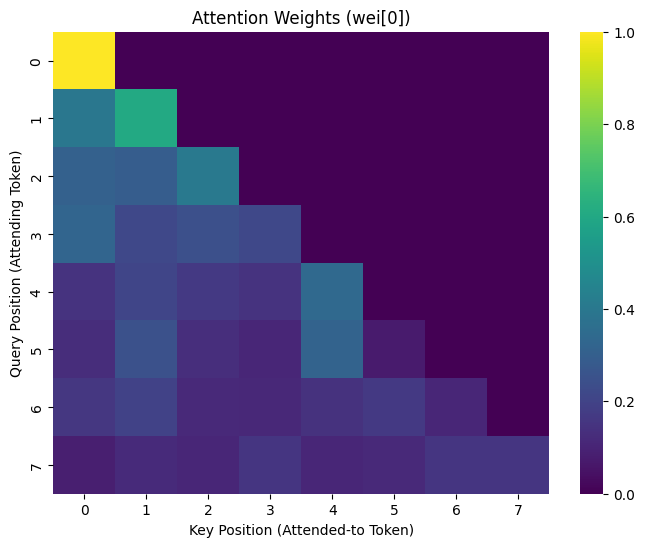

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming wei is available from the previous cell
# We'll visualize the attention weights for the first batch item
attention_weights_to_plot = wei[0].cpu().detach().numpy() # Move to CPU and convert to NumPy

plt.figure(figsize=(8, 6))
sns.heatmap(attention_weights_to_plot, annot=False, cmap='viridis', fmt=".2f")
plt.title('Attention Weights (wei[0])')
plt.xlabel('Key Position (Attended-to Token)')
plt.ylabel('Query Position (Attending Token)')
plt.show()

In this heatmap:
*   The **Y-axis** represents the **query token's position** (the token that is 'looking').
*   The **X-axis** represents the **key token's position** (the token being 'looked at').
*   The **color intensity** indicates the attention weight: brighter colors mean higher attention.

You should observe that:
*   The heatmap is **lower triangular** (or mostly so) because of the masking with `-inf` and subsequent softmax, meaning tokens only attend to themselves and preceding tokens. This is characteristic of a decoder-style self-attention where future information is not allowed.
*   Each row sums to 1 (due to softmax), representing how the attention of a given query token is distributed across its preceding context.

In [42]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3966, 0.6034, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3069, 0.2892, 0.4039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3233, 0.2175, 0.2443, 0.2149, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1479, 0.2034, 0.1663, 0.1455, 0.3369, 0.0000, 0.0000, 0.0000],
        [0.1259, 0.2490, 0.1324, 0.1062, 0.3141, 0.0724, 0.0000, 0.0000],
        [0.1598, 0.1990, 0.1140, 0.1125, 0.1418, 0.1669, 0.1061, 0.0000],
        [0.0845, 0.1197, 0.1078, 0.1537, 0.1086, 0.1146, 0.1558, 0.1553]],
       grad_fn=<SelectBackward0>)

## Notes

1.  **attention as communication**: In the context of self-attention, tokens 'communicate' with each other. Each token sends a 'query' to other tokens and receives information (values) from them based on how well their 'keys' match the query. This forms a communication channel. Can be seen as nodes in direct graph.
2.   **Attention has no notion of space, operates over sets**: Standard self-attention treats the input as an unordered set of tokens. The relative or absolute position of tokens is not inherently captured, which is why **positional encodings** are necessary to inject this information.
3.  **There is no communication across batch dimension**: Attention mechanisms operate independently within each item of a batch. Tokens in one sequence of a batch do not attend to or receive information from tokens in another sequence of the same batch.
4.   **Encoder blocks vs. Decoder blocks**: Encoder blocks typically use multi-head self-attention that allows tokens to attend to all other tokens in the sequence (both past and future). Decoder blocks, especially in language generation, use masked multi-head self-attention, preventing tokens from attending to future tokens, thus preserving the auto-regressive property.
5.   **Attention vs. Self-attention vs. Cross-attention**:
    *   **Attention**: A general mechanism to weigh different parts of an input.
    *   **Self-attention**: A form of attention where the queries, keys, and values all come from the same input sequence.
    *   **Cross-attention**: A form of attention where queries come from one sequence (e.g., decoder output), and keys and values come from a different sequence (e.g., encoder output).
6.  **'Scaled' self-attention. Why divide by sqrt(head_size)**: In scaled dot-product attention, the dot product of queries and keys is divided by the square root of the head size (d_k). This scaling factor is used to prevent the dot products from growing too large, which can push the softmax function into regions with very small gradients, hindering training.

If the weight is not divided by sqrt(head_size), the softmax grows into one-hot encoding(as larger values get larger, smaller ones get smaller). So to prevent it from happening, using divide by sqrt(head_size)

# Self attention Header class

In [43]:
class Head(nn.Module):
  """ one head of self attention"""

  def __init__(self, head_size):
    super().__init__()
    self.key = nn.Linear(n_embd, head_size, bias = False)
    self.query = nn.Linear(n_embd, head_size, bias = False)
    self.value = nn.Linear(n_embd, head_size, bias = False)
    # register buffer
    self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

  def forward(self, x):
    B,T,C = x.shape
    k = self.key(x)
    q = self.query(x)
    # attention scores
    wei = q @ k.transpose(-2,-1) * C**-0.5 # (B,T,C)@(B,C,T) -> (B,T,T)
    # masking the tril -> to not communicate with the future, so a decoder block
    wei = wei.masked_fill(self.tril[:T,:T] ==0, float('-inf'))
    wei = F.softmax(wei, dim = -1)#(B,T,T)

    v = self.value(x)
    out = wei@v #(B,T,T)@(B,T,C) -> (B,T,C)
    return out



# BiGram with self attention in single head

In [54]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

n_embd = 32

class BigramLanguageModel(nn.Module):

  def __init__(self, vocab_size):
    # constructor of parent class nn.Module
    super().__init__()
    #each char from vocab_size directly reads off the logits for next token from a lookup table
    self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
    # returns n_embd -> dimensional vector for each token
    # n_embd -> token embedding
    self.position_embedding_table = nn.Embedding(block_size, n_embd)
    # it will learn a unique n_embd-dimensional embedding for each possible position
    # within the maximum sequence length (block_size).
    self.lm_head = nn.Linear(n_embd, vocab_size)
    # take n_embd token embedding and project up to  vocab_size dim
    # vocab_size logits are predicting next character
    # Single attention Head
    self.sa_head = Head(n_embd)

  def forward(self, idx, targets=None):
    B, T  = idx.shape

    # idx, targets -> shape is (Batch_size,block_size) i.e, (B,T) tensors
    tok_emb = self.token_embedding_table(idx) # (B,T,C)
    pos_emb = self.position_embedding_table(torch.arange(T)) # (T,C)
    x = tok_emb + pos_emb # (B,T,C)

    # Feed the x into self attention head
    x = self.sa_head(x) # (B,T,C)
    logits = self.lm_head(x) # (B,T,vocab_size)

    if targets is None:
        loss = None
    else:
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        # making logits, 2D as cross_entropy expects perdiction to be 2D
        targets = targets.view(B*T)
        # making it 1D
        loss = F.cross_entropy(logits, targets)

    return logits, loss


  def generate(self, idx, max_new_tokens):
    """ considers seq idx and tries to predict max_new_tokens following"""
    # idx is (B, T) array of indices -> current context
    # max_new_tokens -> number of new characters model should generate
    for _ in range(max_new_tokens):

      # crop the idx to the last block_size tokens
      # to make positional_embedding table not go out of scope
      idx_cond = idx[:,-block_size:]
      # get the predictions -> calls the forward method
      logits, loss = self(idx_cond)

      logits = logits[:,-1,:] # becomes (B,C)

      probs = F.softmax(logits, dim=-1) # (B,C)

      idx_next = torch.multinomial(probs,num_samples = 1) # (B,1)

      idx = torch.cat((idx, idx_next), dim=1) # (B,T+1)
    return idx



m = BigramLanguageModel(vocab_size)


optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

for steps in range(4500):
    if steps % 300 == 0:
        losses = estimate_loss()
        print(f"Step {steps} | Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"\nFinal evaluation:")
losses = estimate_loss()
print(f"Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

print(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100))
print(decode(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

Step 0 | Train Loss: 4.2468 | Val Loss: 4.2452
Step 300 | Train Loss: 2.9382 | Val Loss: 2.9583
Step 600 | Train Loss: 2.6537 | Val Loss: 2.6708
Step 900 | Train Loss: 2.5599 | Val Loss: 2.5673
Step 1200 | Train Loss: 2.5208 | Val Loss: 2.5197
Step 1500 | Train Loss: 2.4855 | Val Loss: 2.4954
Step 1800 | Train Loss: 2.4657 | Val Loss: 2.4746
Step 2100 | Train Loss: 2.4503 | Val Loss: 2.4534
Step 2400 | Train Loss: 2.4359 | Val Loss: 2.4552
Step 2700 | Train Loss: 2.4216 | Val Loss: 2.4459

Final evaluation:
Train Loss: 2.4335 | Val Loss: 2.4334
tensor([[ 0, 13, 26, 43, 39, 56, 40, 51, 39, 41, 39, 52, 45, 43,  1, 41, 47, 58,
         46, 43, 58,  0, 14, 59,  1, 57, 43,  1, 46, 47, 52, 43, 52,  1, 39,  1,
         46, 47, 52, 49, 53, 44,  1, 39, 58,  6,  1, 51, 43, 50,  1, 51, 47, 44,
         53, 60, 43,  1, 61, 43,  1, 40, 58, 58, 43, 52,  1, 58, 46, 43, 39, 58,
         47, 56, 44, 53, 59, 50,  1, 56, 47, 57, 58,  1, 51, 43, 56, 52, 47, 50,
          8,  0,  5, 42,  1, 57, 46, 43, 42,

Self attention is having some improvement but not as perfect as needed

# Multi-Head attention
multiple attentions in parallel -> done by using multiple heads, run all of them parellely in a list and then concatenate them over the C dimension

In [48]:
class MultiHeadAttention(nn.Module):
  """ multiple heads of self-attention in parallel"""

  def __init__(self, num_heads, head_size):
    super().__init__()
    # creating a module list fo Heads based on head_size for all the no of heads
    self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

  def forward(self,x):
    # concatenating them in the C -> Channel direction
    return torch.cat([h(x) for h in self.heads], dim=-1)


# BiGram with Mutli Head attention

In [55]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

n_embd = 32

class BigramLanguageModel(nn.Module):

  def __init__(self, vocab_size):
    super().__init__()
    self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
    self.position_embedding_table = nn.Embedding(block_size, n_embd)
    # Multi attention Head -> n_embd = 32 , so 4 channels of 8 dim -> 4* 8 = 32
    # similar to group convolution
    self.sa_head = MultiHeadAttention(4, n_embd//4) # i.e, 4 heads of 8-dimensional self-attention
    self.lm_head = nn.Linear(n_embd, vocab_size)

  def forward(self, idx, targets=None):
    B, T  = idx.shape


    tok_emb = self.token_embedding_table(idx) # (B,T,C)
    pos_emb = self.position_embedding_table(torch.arange(T)) # (T,C)
    x = tok_emb + pos_emb # (B,T,C)


    x = self.sa_head(x) # (B,T,C)
    logits = self.lm_head(x) # (B,T,vocab_size)

    if targets is None:
        loss = None
    else:
        B, T, C = logits.shape
        logits = logits.view(B*T, C)

        targets = targets.view(B*T)

        loss = F.cross_entropy(logits, targets)

    return logits, loss


  def generate(self, idx, max_new_tokens):
    """ considers seq idx and tries to predict max_new_tokens following"""

    for _ in range(max_new_tokens):


      idx_cond = idx[:,-block_size:]

      logits, loss = self(idx_cond)

      logits = logits[:,-1,:] # becomes (B,C)

      probs = F.softmax(logits, dim=-1) # (B,C)

      idx_next = torch.multinomial(probs,num_samples = 1) # (B,1)

      idx = torch.cat((idx, idx_next), dim=1) # (B,T+1)
    return idx



m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

for steps in range(4500):
    if steps % 300 == 0:
        losses = estimate_loss()
        print(f"Step {steps} | Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"\nFinal evaluation:")
losses = estimate_loss()
print(f"Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

print(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100))
print(decode(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

torch.Size([256, 65])
tensor(4.2394, grad_fn=<NllLossBackward0>)
Step 0 | Train Loss: 4.2227 | Val Loss: 4.2226
Step 300 | Train Loss: 2.8402 | Val Loss: 2.8482
Step 600 | Train Loss: 2.6071 | Val Loss: 2.6175
Step 900 | Train Loss: 2.5209 | Val Loss: 2.5235
Step 1200 | Train Loss: 2.4699 | Val Loss: 2.4689
Step 1500 | Train Loss: 2.4201 | Val Loss: 2.4294
Step 1800 | Train Loss: 2.3949 | Val Loss: 2.4017
Step 2100 | Train Loss: 2.3656 | Val Loss: 2.3681
Step 2400 | Train Loss: 2.3427 | Val Loss: 2.3595
Step 2700 | Train Loss: 2.3246 | Val Loss: 2.3454

Final evaluation:
Train Loss: 2.3231 | Val Loss: 2.3249
tensor([[ 0, 13, 26, 33, 24, 13, 10,  0, 32, 53,  6,  1, 46, 43,  1, 41, 56, 43,
          1, 40, 58, 59, 56, 56,  6,  0, 35, 46, 43,  1, 61, 47, 52, 45,  6,  1,
         46, 47, 56, 59, 53, 47, 49, 43, 12,  0, 32, 53, 10,  0, 19,  0, 44, 53,
         52,  1, 54, 53, 52, 58,  1, 40, 58, 58, 43, 52, 43,  1, 39, 56, 39, 58,
          1, 40, 44,  1, 40, 50, 43, 56, 47, 57, 58,  1, 51,

- validation loss has improved from single head attention to multi head attention 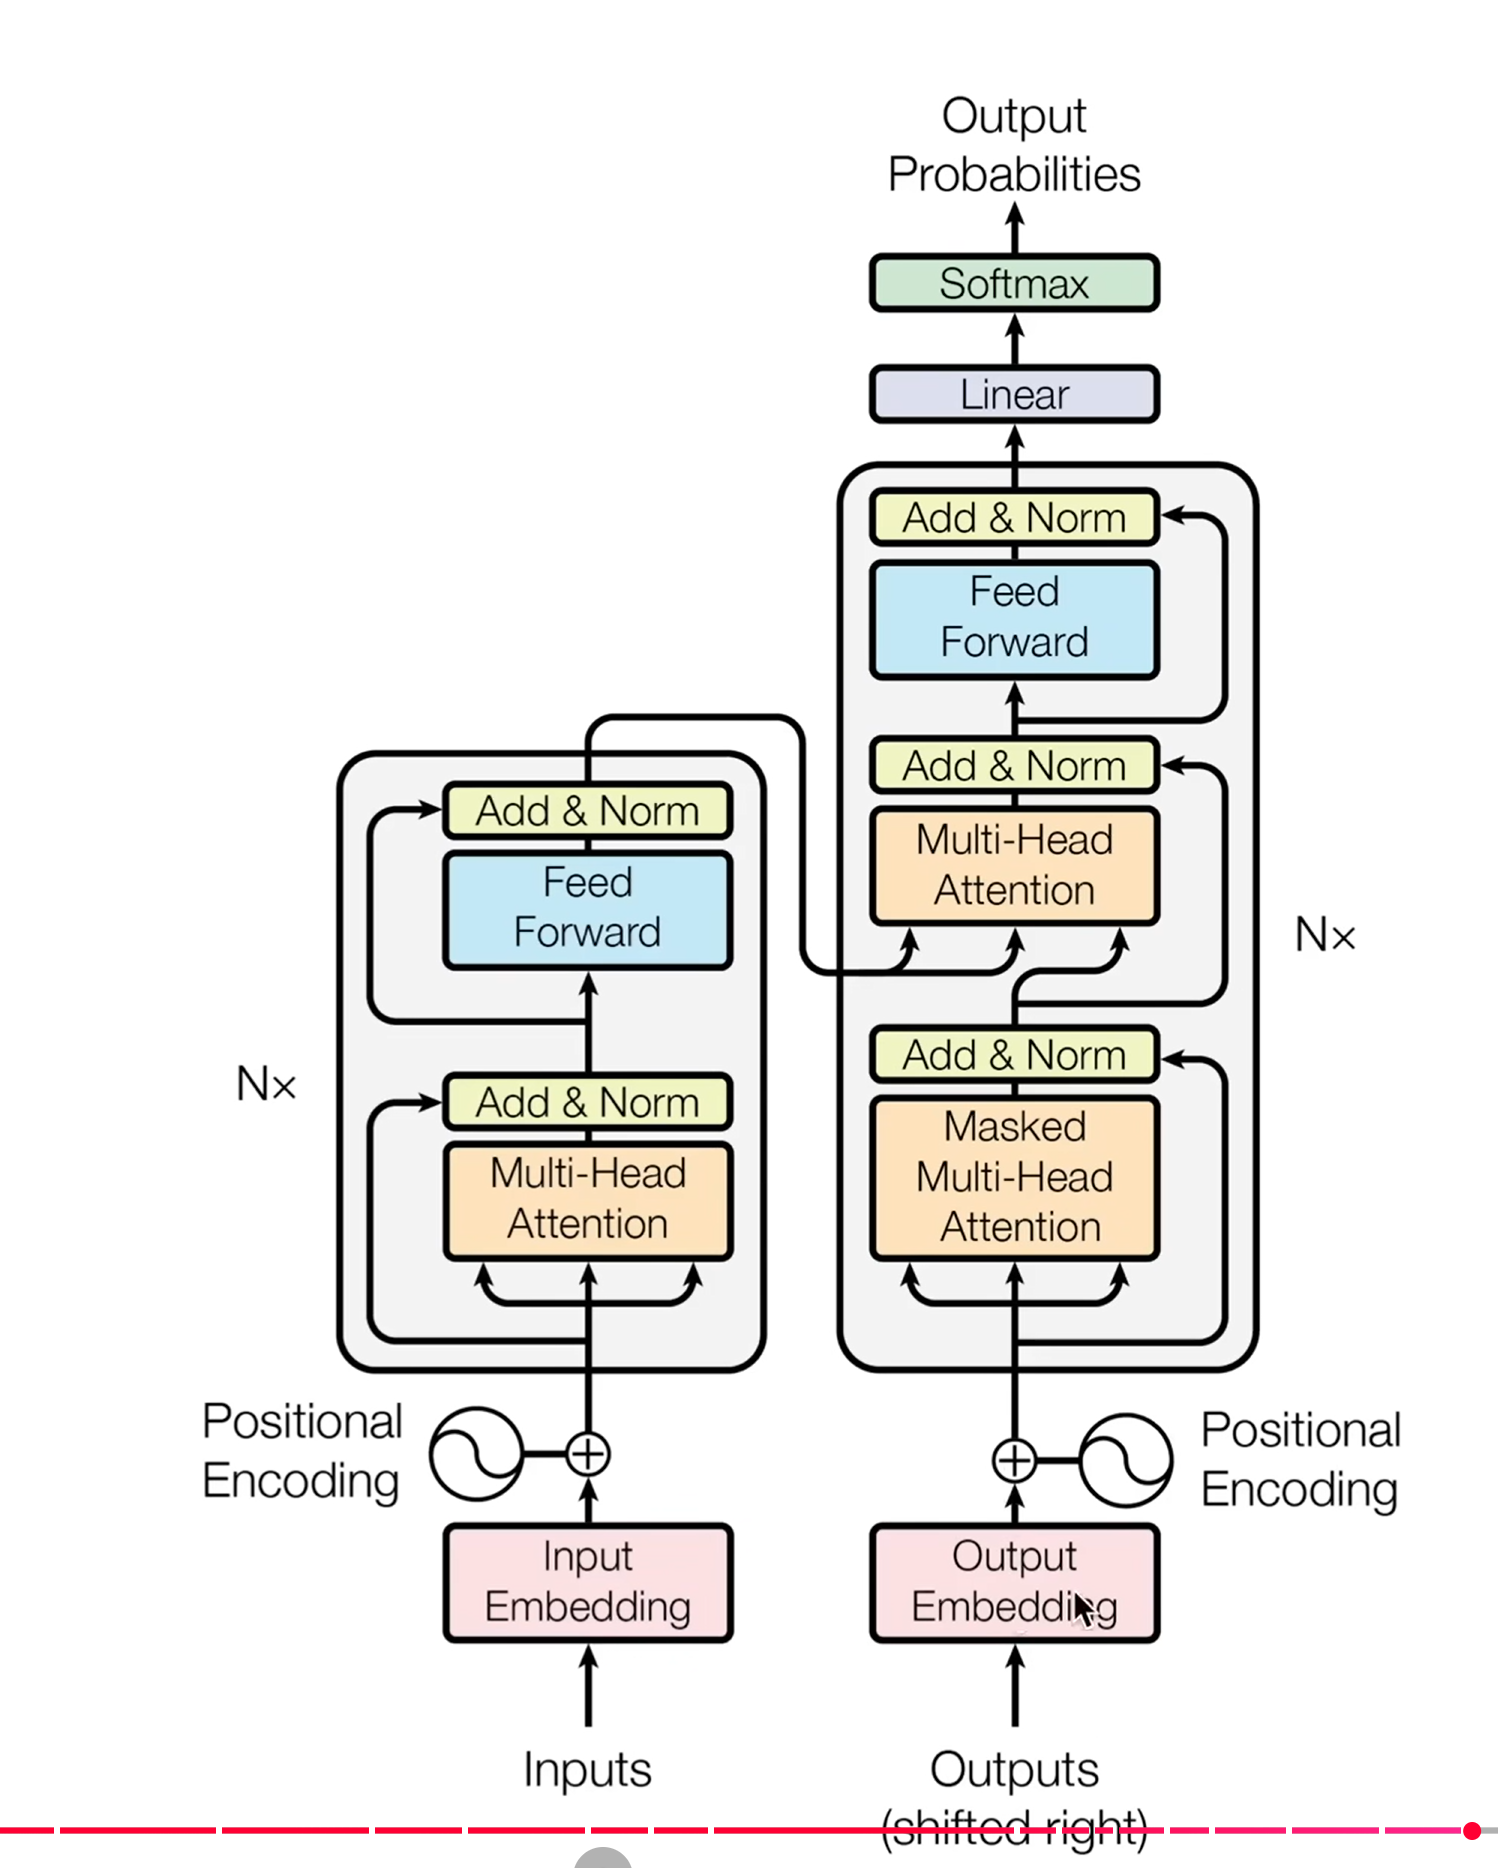

# Feed Forward implementation

In [56]:
class FeedForward(nn.Module):
  """ simple linear layer followed by non-linearity"""

  def __init__(self,n_embd):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(n_embd,n_embd),
      nn.ReLU()
    )

  def forward(self,x):
    return self.net(x)



In [57]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

n_embd = 32

class BigramLanguageModel(nn.Module):

  def __init__(self, vocab_size):
    super().__init__()
    self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
    self.position_embedding_table = nn.Embedding(block_size, n_embd)
    self.sa_head = MultiHeadAttention(4, n_embd//4) # i.e, 4 heads of 8-dimensional self-attention
    # feedforward
    self.ffwd = FeedForward(n_embd)
    self.lm_head = nn.Linear(n_embd, vocab_size)

  def forward(self, idx, targets=None):
    B, T  = idx.shape


    tok_emb = self.token_embedding_table(idx) # (B,T,C)
    pos_emb = self.position_embedding_table(torch.arange(T)) # (T,C)
    x = tok_emb + pos_emb # (B,T,C)
    x = self.sa_head(x) # (B,T,C)
    # feedforward
    x = self.ffwd(x) # (B,T,C)
    logits = self.lm_head(x) # (B,T,vocab_size)

    if targets is None:
        loss = None
    else:
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = targets.view(B*T)
        loss = F.cross_entropy(logits, targets)
    return logits, loss


  def generate(self, idx, max_new_tokens):
    """ considers seq idx and tries to predict max_new_tokens following"""

    for _ in range(max_new_tokens):
      idx_cond = idx[:,-block_size:]
      logits, loss = self(idx_cond)
      logits = logits[:,-1,:] # becomes (B,C)
      probs = F.softmax(logits, dim=-1) # (B,C)
      idx_next = torch.multinomial(probs,num_samples = 1) # (B,1)
      idx = torch.cat((idx, idx_next), dim=1) # (B,T+1)
    return idx



m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

for steps in range(4500):
    if steps % 300 == 0:
        losses = estimate_loss()
        print(f"Step {steps} | Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"\nFinal evaluation:")
losses = estimate_loss()
print(f"Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

print(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100))
print(decode(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

torch.Size([256, 65])
tensor(4.1903, grad_fn=<NllLossBackward0>)
Step 0 | Train Loss: 4.1996 | Val Loss: 4.1995
Step 300 | Train Loss: 2.7609 | Val Loss: 2.7737
Step 600 | Train Loss: 2.5634 | Val Loss: 2.5733
Step 900 | Train Loss: 2.4929 | Val Loss: 2.4792
Step 1200 | Train Loss: 2.4409 | Val Loss: 2.4348
Step 1500 | Train Loss: 2.3911 | Val Loss: 2.4002
Step 1800 | Train Loss: 2.3620 | Val Loss: 2.3672
Step 2100 | Train Loss: 2.3343 | Val Loss: 2.3430
Step 2400 | Train Loss: 2.3102 | Val Loss: 2.3326
Step 2700 | Train Loss: 2.2846 | Val Loss: 2.3050
Step 3000 | Train Loss: 2.2859 | Val Loss: 2.2893
Step 3300 | Train Loss: 2.2754 | Val Loss: 2.2781
Step 3600 | Train Loss: 2.2478 | Val Loss: 2.2737
Step 3900 | Train Loss: 2.2367 | Val Loss: 2.2671
Step 4200 | Train Loss: 2.2258 | Val Loss: 2.2689

Final evaluation:
Train Loss: 2.2164 | Val Loss: 2.2419
tensor([[ 0, 18, 47,  1, 52, 39, 57,  1, 44, 53, 56,  1, 58, 46, 53, 59, 57, 46,
          1, 58, 46, 39, 50, 50, 63,  1, 54, 53, 53, 

- Evaluation loss has further reduced

---

- considering the block architecture
- Block -> interspurses communication and computation
- communication -> done by Multi headed seld attention
- computation is done by -> Feed forward NN



# Block class

In [58]:
class Block(nn.Module):
  """ Transformer block: communication followed by computation"""

  def __init__(self, n_embd, n_head):
    super().__init__()
    head_size = n_embd // n_head
    self.sa = MultiHeadAttention(n_head, head_size)
    self.ffwd = FeedForward(n_embd)

  def forward(self, x):
    x = self.sa(x)
    x = self.ffwd(x)
    return x


In [59]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

n_embd = 32

class BigramLanguageModel(nn.Module):

  def __init__(self, vocab_size):
    super().__init__()
    self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
    self.position_embedding_table = nn.Embedding(block_size, n_embd)
    self.blocks = nn.Sequential(
        Block(n_embd, n_head=4),
        Block(n_embd, n_head=4),
        Block(n_embd, n_head=4),
    )
    self.lm_head = nn.Linear(n_embd, vocab_size)

  def forward(self, idx, targets=None):
    B, T  = idx.shape


    tok_emb = self.token_embedding_table(idx) # (B,T,C)
    pos_emb = self.position_embedding_table(torch.arange(T)) # (T,C)
    x = tok_emb + pos_emb # (B,T,C)

    x = self.blocks(x) # (B,T,C)
    logits = self.lm_head(x) # (B,T,vocab_size)

    if targets is None:
        loss = None
    else:
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = targets.view(B*T)
        loss = F.cross_entropy(logits, targets)
    return logits, loss


  def generate(self, idx, max_new_tokens):
    """ considers seq idx and tries to predict max_new_tokens following"""

    for _ in range(max_new_tokens):
      idx_cond = idx[:,-block_size:]
      logits, loss = self(idx_cond)
      logits = logits[:,-1,:] # becomes (B,C)
      probs = F.softmax(logits, dim=-1) # (B,C)
      idx_next = torch.multinomial(probs,num_samples = 1) # (B,1)
      idx = torch.cat((idx, idx_next), dim=1) # (B,T+1)
    return idx



m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

for steps in range(4500):
    if steps % 300 == 0:
        losses = estimate_loss()
        print(f"Step {steps} | Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"\nFinal evaluation:")
losses = estimate_loss()
print(f"Train Loss: {losses['train']:.4f} | Val Loss: {losses['val']:.4f}")

print(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100))
print(decode(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

torch.Size([256, 65])
tensor(4.2031, grad_fn=<NllLossBackward0>)
Step 0 | Train Loss: 4.2116 | Val Loss: 4.2078
Step 300 | Train Loss: 3.2377 | Val Loss: 3.2682
Step 600 | Train Loss: 3.0039 | Val Loss: 3.0053
Step 900 | Train Loss: 2.7876 | Val Loss: 2.7823
Step 1200 | Train Loss: 2.6457 | Val Loss: 2.6511
Step 1500 | Train Loss: 2.5619 | Val Loss: 2.5650
Step 1800 | Train Loss: 2.5299 | Val Loss: 2.5272
Step 2100 | Train Loss: 2.4761 | Val Loss: 2.4775
Step 2400 | Train Loss: 2.4536 | Val Loss: 2.4524
Step 2700 | Train Loss: 2.4414 | Val Loss: 2.4466
Step 3000 | Train Loss: 2.4115 | Val Loss: 2.4116
Step 3300 | Train Loss: 2.3984 | Val Loss: 2.3841
Step 3600 | Train Loss: 2.3872 | Val Loss: 2.3826
Step 3900 | Train Loss: 2.3718 | Val Loss: 2.3804
Step 4200 | Train Loss: 2.3537 | Val Loss: 2.3652

Final evaluation:
Train Loss: 2.3530 | Val Loss: 2.3495
tensor([[ 0, 24, 59, 58, 43, 56, 41,  1, 53, 42,  1, 63, 53, 59, 50,  1, 46, 43,
         39, 58, 43, 56,  1, 51, 39, 58,  1, 51, 63, 

- adding block doesn't just add a lot to the training quality
- Residual connections improve the training quality -> this is a skip connection or residual connection
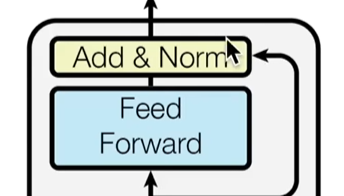

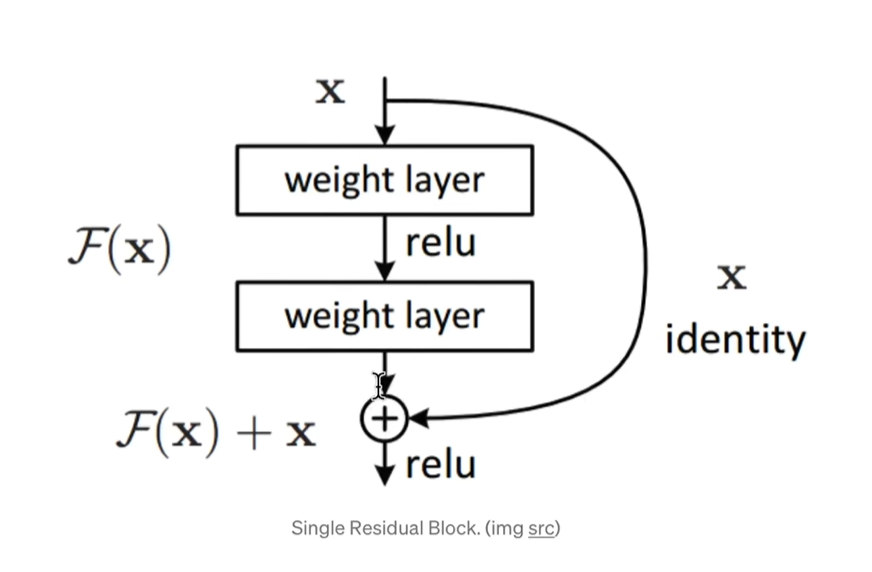
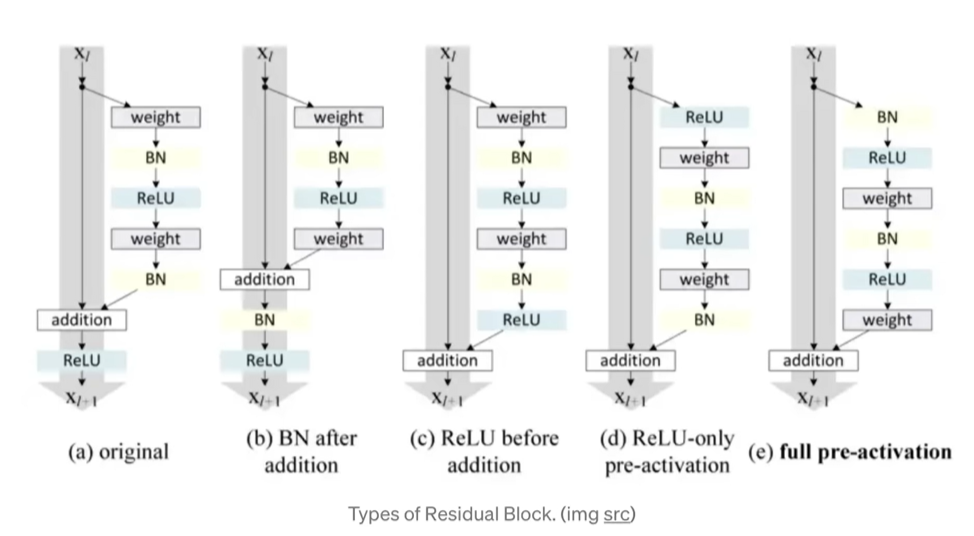


- Introducing residual conenctions to the code